#### Exercise 1: Lab1_3: finite-differences with tolerance

* Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
* Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explain in words the strategy.
* Compare with Fourier serie. How many terms in the fourier serie are necesary to obtain a $\text{tol}=10^{-3}$.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Solución Numérica

In [3]:
#****** LaplaceLine.py in Paez, *************************************
#       Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
def Laplace2D(V_ini, tol, x, y, max_iter=10000): #Metodo diferencias finitas
    V = V_ini.copy()
    Nmax = V.shape[0]

    for iteration in range(max_iter):
        V_old = V.copy()

        for i in range(1, Nmax-1):
            for j in range(1, Nmax-1):
                V[i,j] = 0.25*(V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])

        # criterio de convergencia
        error = np.linalg.norm(np.abs(V - V_old))
        if error < tol:
            print(f"Convergió en {iteration} iteraciones")
            break

    X, Y = np.meshgrid(x, y)
    Z = V  # ya es la solución en la malla

    return X, Y, Z



Convergió en 891 iteraciones


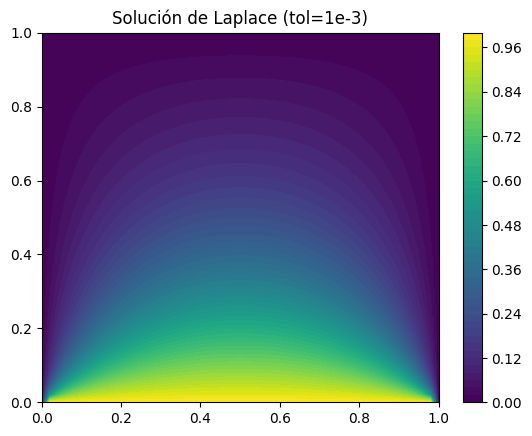

In [4]:
#Definimos las variables y sus intervalos
N = 50 #espaciado
x = np.linspace(0,1,N)
y = np.linspace(0,1,N)

V = np.zeros((N,N)) #Creamos nuestro arreglo vacio de potencial a encontrar

# Definimos las condiciones de frontera
V[0,:] = 1   # borde inferior (y=0)
V[-1,:] = 0  # borde superior (y=1)
V[:,0] = 0   # borde izquierdo (x=0)
V[:,-1] = 0  # borde derecho (x=1)

X, Y, Z = Laplace2D(V, tol=1e-3, x=x, y=y) #Resolvemos el potencial con la funcion definida previamente (modificacion de la que nos dio el profe)

#Graficando ando
plt.contourf(X, Y, Z, 50)
plt.colorbar()
plt.title("Solución de Laplace (tol=1e-3)")
plt.show()

La estrategia usada en este caso es; a cada actualización en el interior de la malla de mi nuevo potencial V que es determinada por el método de diferencias finitas (el promedio de los valores de sus vecinos), está siendo comparada en módulo (gracias a la función np.linalg.norm), con su valor anterior (el de V_old) para una tolerancia de $10^{-3}$ que no debe superar como método de convergencia para establecer los valores del potencial en la malla (claramente cumpliendo las condiciones de frontera).

## Solución Analítica

In [5]:
#Gracias a que el profe nos la suministro
def serie_fourier(X, Y, N_terms):
    U = np.zeros_like(X)

    for n in range(1, N_terms+1):
        if n % 2 == 1:  # solo impares
            An = (4 / (n * np.pi)) / np.sinh(n * np.pi)
            U += An * np.sin(n * np.pi * X) * np.sinh(n * np.pi * Y)

    return U

In [13]:
#creando la malla
N = 50
x_1 = np.linspace(0,1,N)
y_1 = np.linspace(0,1,N)
X, Y = np.meshgrid(x_1, y_1)

# condiciones de frontera
V_1 = np.zeros((N,N))
V_1[-1,:] = 1  # u(x,1)=1

# solucion numerica
V_fd = Laplace2D(V_1, 1e-3, x_1, y_1)

# comparar para series con 1,2....., 100 terminos
tol = 1e-3
max_terms = 150

for Nt in range(1, max_terms+1):
    V_fourier = serie_fourier(X, Y, Nt)
    error = np.max(np.abs(V_fourier - V_fd))

    print(f"N = {Nt}, error = {error:.5e}")

    if error < tol:
        print(f"\n Se alcanza tol = {tol} con N = {Nt} términos")
        break

Convergió en 914 iteraciones
N = 1, error = 1.00000e+00
N = 2, error = 1.00000e+00
N = 3, error = 1.00000e+00
N = 4, error = 1.00000e+00
N = 5, error = 1.02465e+00
N = 6, error = 1.02465e+00
N = 7, error = 1.06134e+00
N = 8, error = 1.06134e+00
N = 9, error = 1.07987e+00
N = 10, error = 1.07987e+00
N = 11, error = 1.09924e+00
N = 12, error = 1.09924e+00
N = 13, error = 1.09710e+00
N = 14, error = 1.09710e+00
N = 15, error = 1.11863e+00
N = 16, error = 1.11863e+00
N = 17, error = 1.10906e+00
N = 18, error = 1.10906e+00
N = 19, error = 1.10143e+00
N = 20, error = 1.10143e+00
N = 21, error = 1.12774e+00
N = 22, error = 1.12774e+00
N = 23, error = 1.13832e+00
N = 24, error = 1.13832e+00
N = 25, error = 1.13506e+00
N = 26, error = 1.13506e+00
N = 27, error = 1.12020e+00
N = 28, error = 1.12020e+00
N = 29, error = 1.09625e+00
N = 30, error = 1.09625e+00
N = 31, error = 1.06584e+00
N = 32, error = 1.06584e+00
N = 33, error = 1.04939e+00
N = 34, error = 1.04939e+00
N = 35, error = 1.07784e+00


Para series entre 1 y 150 términos, la tolerancia se sigue mantieniendo en el mismo orden de magnitud, para que se de la convergencia se requerirá de una cantidad de términos que exigen enormes recursos computacionales de tiempo y memoria.

